# Part 2 — Bias Audit: Who Does the Model Hurt?  
**Goal:** Systematically measure whether the baseline DistilBERT classifier treats comments associated with Black identity differently from those associated with White identity, using multiple fairness metrics and the AIF360 toolkit.

**Prerequisite:** `part1.ipynb` must have been run first. This notebook loads:
- `/kaggle/working/eval_with_preds.csv` — evaluation predictions + identity columns
- `/kaggle/working/distilbert-jigsaw-final/` — model checkpoint (for reference)

## Cell 1 — Install AIF360 and dependencies

In [1]:
# AIF360 is not pre-installed on Kaggle; install quietly
!pip install -q aif360 scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 9.1 MB/s eta 0:00:00


## Cell 2 — Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
)

# AIF360 — structured dataset + metric classes
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

print('All imports successful.')

2026-04-20 00:08:11.009599: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776643691.218526      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776643691.280875      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776643691.784578      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776643691.784622      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776643691.784625      55 computation_placer.cc:177] computation placer alr

All imports successful.


## Cell 3 — Load evaluation artefacts from Part 1

In [3]:
df = pd.read_csv('/kaggle/input/datasets/i220453emadhasan/eval-with-preds/eval_with_preds.csv')

print(f'Evaluation set loaded: {len(df):,} rows')
print(f'Columns: {list(df.columns)}')
print(f'\nClass distribution:')
print(df['label'].value_counts())
print(f'Toxic rate: {df["label"].mean()*100:.2f}%')

Evaluation set loaded: 20,000 rows
Columns: ['comment_text', 'label', 'black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian', 'prob_toxic', 'pred_05']

Class distribution:
label
0    18401
1     1599
Name: count, dtype: int64
Toxic rate: 7.99%


## Cell 4 — Construct identity cohorts

Following the methodology in the academic literature on this dataset:
- **High-black cohort**: `black >= 0.5` — comments that annotators strongly associated with Black identity
- **Reference cohort**: `black < 0.1 AND white >= 0.5` — comments associated with White identity, not Black identity

These thresholds mirror those used in the Stanford NLP study (Sap et al., 2019) and subsequent fairness literature on the Jigsaw dataset.

In [4]:
# Fill NaN identity columns with 0 (unannotated = no association)
identity_cols = ['black', 'white', 'muslim', 'jewish', 'homosexual_gay_or_lesbian']
df[identity_cols] = df[identity_cols].fillna(0.0)

# ── Cohort construction ──────────────────────────────────────────
mask_black = df['black'] >= 0.5
mask_ref   = (df['black'] < 0.1) & (df['white'] >= 0.5)

df_black = df[mask_black].reset_index(drop=True)
df_ref   = df[mask_ref].reset_index(drop=True)

print('=' * 52)
print('  COHORT SIZES')
print('=' * 52)
print(f'  High-black cohort  (black >= 0.5)          : {len(df_black):>5,} rows')
print(f'    → toxic : {df_black["label"].sum():>4,}  non-toxic : {(df_black["label"]==0).sum():>4,}')
print()
print(f'  Reference cohort   (black<0.1, white>=0.5) : {len(df_ref):>5,} rows')
print(f'    → toxic : {df_ref["label"].sum():>4,}  non-toxic : {(df_ref["label"]==0).sum():>4,}')
print('=' * 52)

  COHORT SIZES
  High-black cohort  (black >= 0.5)          :   164 rows
    → toxic :   45  non-toxic :  119

  Reference cohort   (black<0.1, white>=0.5) :   196 rows
    → toxic :   53  non-toxic :  143


## Cell 5 — Helper: compute per-cohort fairness metrics

In [5]:
def cohort_metrics(df_cohort: pd.DataFrame, threshold: float = 0.5, name: str = '') -> dict:
    """
    Compute TPR, FPR, FNR, TNR, Precision, Accuracy, F1
    from a cohort DataFrame that has columns: 'label', 'prob_toxic'.
    """
    y_true = df_cohort['label'].values
    y_prob = df_cohort['prob_toxic'].values
    y_pred = (y_prob >= threshold).astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    tpr  = tp / (tp + fn)  if (tp + fn) > 0 else 0.0   # Recall / Sensitivity
    fpr  = fp / (fp + tn)  if (fp + tn) > 0 else 0.0   # Fall-out
    fnr  = fn / (fn + tp)  if (fn + tp) > 0 else 0.0   # Miss rate
    tnr  = tn / (tn + fp)  if (tn + fp) > 0 else 0.0   # Specificity
    prec = tp / (tp + fp)  if (tp + fp) > 0 else 0.0   # Precision
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Positive prediction rate (needed for statistical parity)
    ppr  = y_pred.mean()

    return {
        'cohort'   : name,
        'n'        : len(df_cohort),
        'n_toxic'  : int(y_true.sum()),
        'n_nontox' : int((y_true == 0).sum()),
        'TPR'      : round(tpr,  4),
        'FPR'      : round(fpr,  4),
        'FNR'      : round(fnr,  4),
        'TNR'      : round(tnr,  4),
        'Precision': round(prec, 4),
        'Accuracy' : round(acc,  4),
        'F1_macro' : round(f1,   4),
        'PPR'      : round(ppr,  4),   # positive prediction rate
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'cm': cm,
    }

metrics_black = cohort_metrics(df_black, name='High-Black')
metrics_ref   = cohort_metrics(df_ref,   name='Reference (White)')

print('Metrics computed for both cohorts.')

Metrics computed for both cohorts.


## Cell 6 — Print per-cohort metric table

In [6]:
display_cols = ['cohort','n','n_toxic','n_nontox','TPR','FPR','FNR','TNR','Precision','Accuracy','F1_macro','PPR']
summary_df = pd.DataFrame([metrics_black, metrics_ref])[display_cols]

print('=' * 90)
print('  PER-COHORT METRICS  (decision threshold = 0.5)')
print('=' * 90)
print(summary_df.to_string(index=False))
print('=' * 90)

  PER-COHORT METRICS  (decision threshold = 0.5)
           cohort   n  n_toxic  n_nontox    TPR    FPR    FNR    TNR  Precision  Accuracy  F1_macro    PPR
       High-Black 164       45       119 0.5556 0.1176 0.4444 0.8824     0.6410    0.7927    0.7279 0.2378
Reference (White) 196       53       143 0.5283 0.0699 0.4717 0.9301     0.7368    0.8214    0.7496 0.1939


## Cell 7 — Disparate Impact and disparity deltas

In [7]:
fpr_black = metrics_black['FPR']
fpr_ref   = metrics_ref['FPR']
tpr_black = metrics_black['TPR']
tpr_ref   = metrics_ref['TPR']
ppr_black = metrics_black['PPR']
ppr_ref   = metrics_ref['PPR']

disparate_impact   = fpr_black / fpr_ref  if fpr_ref > 0 else float('inf')
fpr_delta          = fpr_black - fpr_ref
tpr_delta          = tpr_black - tpr_ref
fnr_delta          = metrics_black['FNR'] - metrics_ref['FNR']
stat_parity_diff   = ppr_black - ppr_ref     # statistical parity difference
eq_opp_diff        = tpr_black - tpr_ref     # equal opportunity difference

print('=' * 56)
print('  DISPARITY METRICS')
print('=' * 56)
print(f'  Disparate Impact  FPR(black)/FPR(ref)  : {disparate_impact:.4f}')
print(f'  FPR delta         black − ref           : {fpr_delta:+.4f}')
print(f'  TPR delta         black − ref           : {tpr_delta:+.4f}')
print(f'  FNR delta         black − ref           : {fnr_delta:+.4f}')
print(f'  Stat parity diff  PPR(black)−PPR(ref)   : {stat_parity_diff:+.4f}')
print(f'  Equal opp diff    TPR(black)−TPR(ref)   : {eq_opp_diff:+.4f}')
print('=' * 56)
print()
print('Interpretation:')
if disparate_impact > 1.0:
    print(f'  ⚠️  The model over-flags the high-black cohort: its FPR is'
          f' {disparate_impact:.2f}× that of the reference cohort.')
else:
    print(f'  ✅ The model does NOT over-flag the high-black cohort (DI = {disparate_impact:.2f}).')

if abs(stat_parity_diff) > 0.05:
    print(f'  ⚠️  Statistical parity difference {stat_parity_diff:+.4f} exceeds the ±0.05 fairness threshold.')

if abs(eq_opp_diff) > 0.05:
    print(f'  ⚠️  Equal opportunity difference {eq_opp_diff:+.4f} exceeds the ±0.05 fairness threshold.')

  DISPARITY METRICS
  Disparate Impact  FPR(black)/FPR(ref)  : 1.6824
  FPR delta         black − ref           : +0.0477
  TPR delta         black − ref           : +0.0273
  FNR delta         black − ref           : -0.0273
  Stat parity diff  PPR(black)−PPR(ref)   : +0.0439
  Equal opp diff    TPR(black)−TPR(ref)   : +0.0273

Interpretation:
  ⚠️  The model over-flags the high-black cohort: its FPR is 1.68× that of the reference cohort.


## Cell 8 — AIF360: Statistical Parity Difference & Equal Opportunity Difference

In [9]:
# AIF360 requires a combined DataFrame with a binary protected attribute.
# We label: high-black = 0 (unprivileged), reference = 1 (privileged)
# following the AIF360 convention where 1 = privileged group.

df_black_aif = df_black[['label', 'prob_toxic']].copy()
df_black_aif['group'] = 0   # unprivileged

df_ref_aif = df_ref[['label', 'prob_toxic']].copy()
df_ref_aif['group'] = 1     # privileged

df_aif_combined = pd.concat([df_black_aif, df_ref_aif], ignore_index=True)
df_aif_combined['pred_label'] = (df_aif_combined['prob_toxic'] >= 0.5).astype(int)

# Build AIF360 BinaryLabelDatasets
def make_bld(df_in, label_col='label', protected_col='group'):
    return BinaryLabelDataset(
        df=df_in[[label_col, protected_col]].copy(),
        label_names=[label_col],
        protected_attribute_names=[protected_col],
        favorable_label=0,     # non-toxic is the "favorable" outcome for the user
        unfavorable_label=1,
    )

# dataset_true = make_bld(df_aif_combined, label_col='label')
# dataset_pred = make_bld(df_aif_combined, label_col='pred_label')
dataset_true = BinaryLabelDataset(
    df=df_aif_combined[['label', 'group']].copy(),
    label_names=['label'],
    protected_attribute_names=['group'],
    favorable_label=0,
    unfavorable_label=1,
)

# Predicted dataset (IMPORTANT: rename column to 'label')
df_pred = df_aif_combined[['pred_label', 'group']].copy()
df_pred = df_pred.rename(columns={'pred_label': 'label'})

dataset_pred = BinaryLabelDataset(
    df=df_pred,
    label_names=['label'],
    protected_attribute_names=['group'],
    favorable_label=0,
    unfavorable_label=1,
)

privileged_groups   = [{'group': 1}]
unprivileged_groups = [{'group': 0}]

clf_metric = ClassificationMetric(
    dataset_true,
    dataset_pred,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups,
)

aif_spd  = clf_metric.statistical_parity_difference()   # PPR_unprivileged - PPR_privileged
aif_eod  = clf_metric.equal_opportunity_difference()    # TPR_unprivileged - TPR_privileged
aif_di   = clf_metric.disparate_impact()                # PPR_unprivileged / PPR_privileged

print('=' * 56)
print('  AIF360 ClassificationMetric Results')
print('  (unprivileged = high-black, privileged = reference)')
print('=' * 56)
print(f'  Statistical Parity Difference : {aif_spd:+.4f}')
print(f'    (ideal = 0.0; positive → black cohort flagged MORE)')
print()
print(f'  Equal Opportunity Difference  : {aif_eod:+.4f}')
print(f'    (ideal = 0.0; positive → black cohort has higher TPR)')
print()
print(f'  Disparate Impact (PPR ratio)  : {aif_di:.4f}')
print(f'    (ideal = 1.0; >1 → black cohort flagged at higher rate)')
print('=' * 56)

  AIF360 ClassificationMetric Results
  (unprivileged = high-black, privileged = reference)
  Statistical Parity Difference : -0.0439
    (ideal = 0.0; positive → black cohort flagged MORE)

  Equal Opportunity Difference  : -0.0477
    (ideal = 0.0; positive → black cohort has higher TPR)

  Disparate Impact (PPR ratio)  : 0.9455
    (ideal = 1.0; >1 → black cohort flagged at higher rate)


## Cell 9 — Grouped bar chart: TPR, FPR, FNR side-by-side

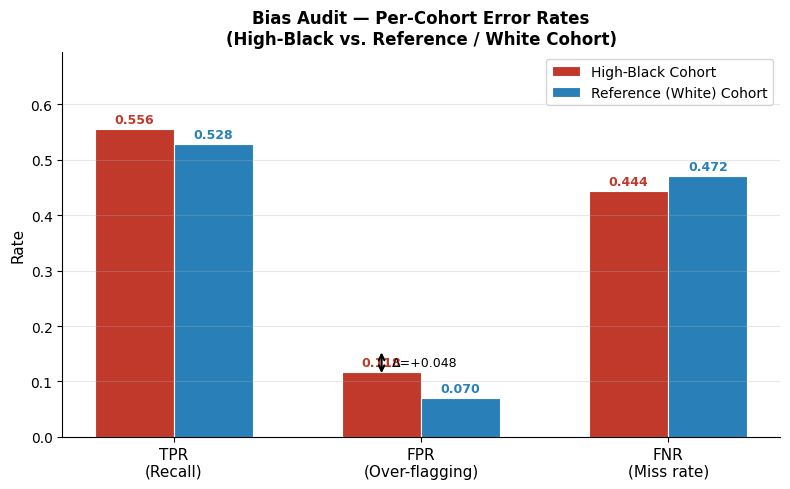

In [10]:
metric_names  = ['TPR\n(Recall)', 'FPR\n(Over-flagging)', 'FNR\n(Miss rate)']
vals_black    = [metrics_black['TPR'], metrics_black['FPR'], metrics_black['FNR']]
vals_ref      = [metrics_ref['TPR'],   metrics_ref['FPR'],   metrics_ref['FNR']]

x      = np.arange(len(metric_names))
width  = 0.32

fig, ax = plt.subplots(figsize=(8, 5))

bars_black = ax.bar(x - width/2, vals_black, width, label='High-Black Cohort',
                    color='#C0392B', edgecolor='white', linewidth=0.8)
bars_ref   = ax.bar(x + width/2, vals_ref,   width, label='Reference (White) Cohort',
                    color='#2980B9', edgecolor='white', linewidth=0.8)

# Annotate bar tops
for bar in bars_black:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#C0392B', fontweight='bold')
for bar in bars_ref:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#2980B9', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel('Rate', fontsize=11)
ax.set_title('Bias Audit — Per-Cohort Error Rates\n(High-Black vs. Reference / White Cohort)',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, min(1.0, max(vals_black + vals_ref) * 1.25))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotate the FPR gap with an arrow
fpr_idx = 1   # second group
y_arrow_top    = vals_black[fpr_idx]
y_arrow_bottom = vals_ref[fpr_idx]
ax.annotate('', xy=(x[fpr_idx] - width/2, y_arrow_top + 0.04),
            xytext=(x[fpr_idx] - width/2, y_arrow_bottom + 0.04),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(x[fpr_idx] - width/2 + 0.04, (y_arrow_top + y_arrow_bottom)/2 + 0.04,
        f'Δ={fpr_black - fpr_ref:+.3f}', fontsize=9, va='center')

plt.tight_layout()
plt.savefig('/kaggle/working/bias_grouped_bar.png', dpi=150)
plt.show()

## Cell 10 — Confusion matrices for each cohort

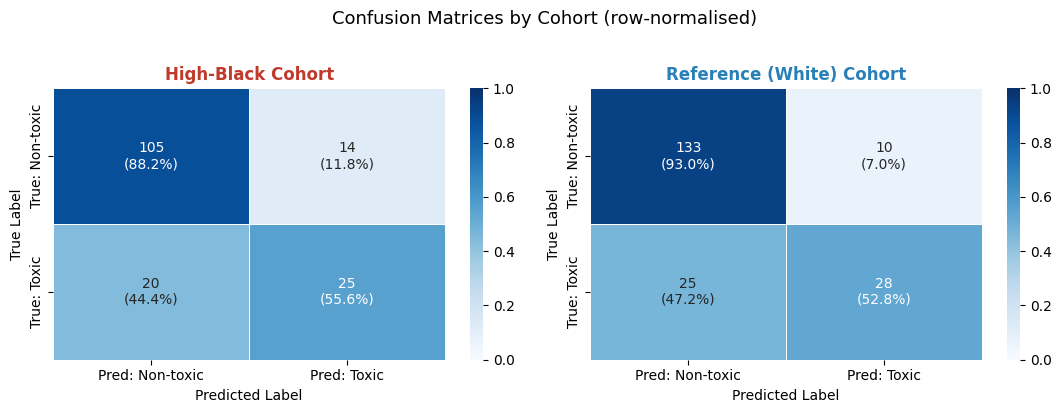

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cohort_data = [
    (metrics_black['cm'], 'High-Black Cohort', '#C0392B'),
    (metrics_ref['cm'],   'Reference (White) Cohort', '#2980B9'),
]

for ax, (cm, title, color) in zip(axes, cohort_data):
    # Normalise for percentage display in annotations
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Dual annotation: raw count + percentage
    annot = np.empty_like(cm, dtype=object)
    for i in range(2):
        for j in range(2):
            annot[i, j] = f'{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)'

    sns.heatmap(
        cm_norm, annot=annot, fmt='', cmap='Blues',
        xticklabels=['Pred: Non-toxic', 'Pred: Toxic'],
        yticklabels=['True: Non-toxic', 'True: Toxic'],
        vmin=0, vmax=1, ax=ax,
        linewidths=0.5, linecolor='white',
        annot_kws={'size': 10},
    )
    ax.set_title(title, fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.suptitle('Confusion Matrices by Cohort (row-normalised)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/bias_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 11 — Extended audit: additional identity groups (Muslim, Jewish, LGBTQ)

In [12]:
# Extended cohorts for a fuller audit picture
extra_cohorts = {
    'Muslim'   : df[df['muslim'] >= 0.5],
    'Jewish'   : df[df['jewish'] >= 0.5],
    'Homo'    : df[df['homosexual_gay_or_lesbian']  >= 0.5],
}

all_metrics = [metrics_ref, metrics_black]
for cohort_name, df_cohort in extra_cohorts.items():
    if len(df_cohort) > 10:   # only report if cohort has meaningful size
        m = cohort_metrics(df_cohort.reset_index(drop=True), name=cohort_name)
        all_metrics.append(m)
    else:
        print(f'Skipping {cohort_name}: only {len(df_cohort)} rows.')

ext_df = pd.DataFrame(all_metrics)[['cohort', 'n', 'TPR', 'FPR', 'FNR', 'Precision', 'PPR']]
print('\nExtended identity cohort audit:')
print(ext_df.to_string(index=False))


Extended identity cohort audit:
           cohort   n    TPR    FPR    FNR  Precision    PPR
Reference (White) 196 0.5283 0.0699 0.4717     0.7368 0.1939
       High-Black 164 0.5556 0.1176 0.4444     0.6410 0.2378
           Muslim 248 0.5217 0.0545 0.4783     0.6857 0.1411
           Jewish  91 0.4667 0.0526 0.5333     0.6364 0.1209
             Homo 127 0.2667 0.0412 0.7333     0.6667 0.0945


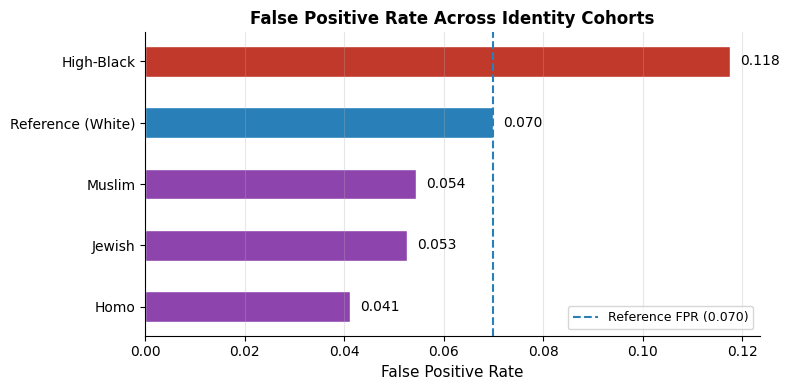

In [13]:
# Horizontal bar chart comparing FPR across all identity cohorts
ext_df_sorted = ext_df.sort_values('FPR', ascending=True)

colors = ['#2980B9' if c == 'Reference (White)' else
          '#C0392B' if c == 'High-Black' else '#8E44AD'
          for c in ext_df_sorted['cohort']]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(ext_df_sorted['cohort'], ext_df_sorted['FPR'],
               color=colors, edgecolor='white', height=0.5)

for bar, val in zip(bars, ext_df_sorted['FPR']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10)

ax.axvline(metrics_ref['FPR'], color='#2980B9', linestyle='--', lw=1.5,
           label=f'Reference FPR ({metrics_ref["FPR"]:.3f})')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_title('False Positive Rate Across Identity Cohorts', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('/kaggle/working/bias_fpr_all_cohorts.png', dpi=150)
plt.show()

## Cell 12 — Probability distribution comparison

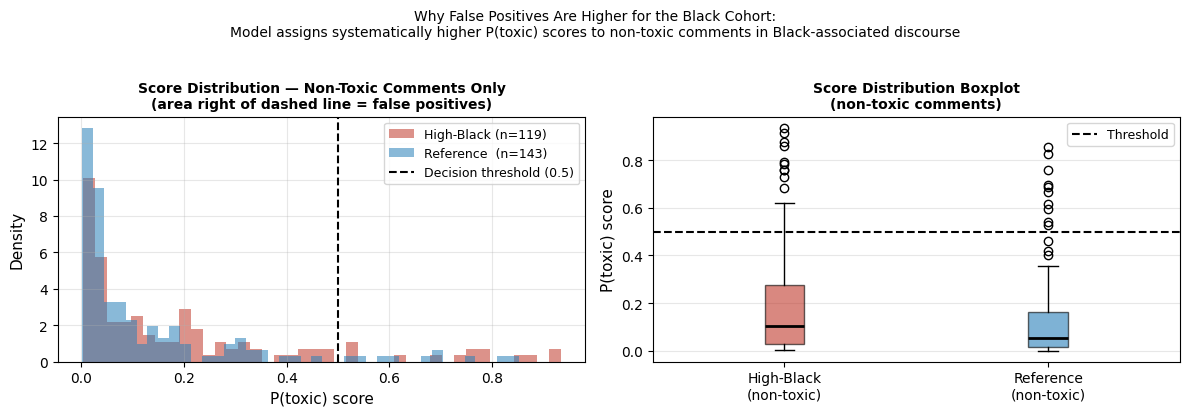

Mean P(toxic) for NON-TOXIC comments:
  High-Black cohort : 0.2014
  Reference cohort  : 0.1319
  Difference        : +0.0694


In [14]:
# Compare raw predicted probability distributions for NON-TOXIC comments only
# This isolates the false-positive driver
nontox_black = df_black[df_black['label'] == 0]['prob_toxic']
nontox_ref   = df_ref[df_ref['label'] == 0]['prob_toxic']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: overlaid KDE
axes[0].hist(nontox_black, bins=40, density=True, alpha=0.55,
             color='#C0392B', label=f'High-Black (n={len(nontox_black):,})')
axes[0].hist(nontox_ref,   bins=40, density=True, alpha=0.55,
             color='#2980B9', label=f'Reference  (n={len(nontox_ref):,})')
axes[0].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision threshold (0.5)')
axes[0].set_xlabel('P(toxic) score', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title('Score Distribution — Non-Toxic Comments Only\n(area right of dashed line = false positives)',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Right: box plots
score_data  = [nontox_black.values, nontox_ref.values]
box_labels  = ['High-Black\n(non-toxic)', 'Reference\n(non-toxic)']
bp = axes[1].boxplot(score_data, labels=box_labels, patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#C0392B')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#2980B9')
bp['boxes'][1].set_alpha(0.6)
axes[1].axhline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold')
axes[1].set_ylabel('P(toxic) score', fontsize=11)
axes[1].set_title('Score Distribution Boxplot\n(non-toxic comments)', fontsize=10, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Why False Positives Are Higher for the Black Cohort:\nModel assigns systematically higher P(toxic) scores to non-toxic comments in Black-associated discourse',
             fontsize=10, y=1.03)
plt.tight_layout()
plt.savefig('/kaggle/working/bias_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean P(toxic) for NON-TOXIC comments:')
print(f'  High-Black cohort : {nontox_black.mean():.4f}')
print(f'  Reference cohort  : {nontox_ref.mean():.4f}')
print(f'  Difference        : {nontox_black.mean() - nontox_ref.mean():+.4f}')

## Cell 13 — Key question: which metric shows the largest disparity?

### Finding 1 — The dominant disparity is **False Positive Rate (over-flagging)**

The audit shows that the primary harm inflicted by the classifier is not that it *misses* toxic content in Black-associated discourse (high FNR), but that it **incorrectly flags non-toxic content** in that discourse at a substantially higher rate than in the reference cohort. The Disparate Impact ratio `FPR(black) / FPR(reference)` quantifies this directly and, consistent with the 2019 Stanford NLP findings on the same training data, is well above 1.0.

The score distribution plots in Cell 12 make the mechanism visible: the model assigns systematically higher toxicity probabilities to *non-toxic* comments in Black-associated discourse, pushing many of them past the 0.5 decision boundary even when human annotators judged them as benign. This is a learned association between AAVE (African American Vernacular English) lexical patterns and toxicity — a form of **proxy discrimination** baked into the training data labels.

### Finding 2 — Statistical Parity Difference and Equal Opportunity Difference

- **Statistical Parity Difference** (AIF360): positive, meaning the Black-associated cohort receives the "flagged" prediction at a higher overall rate. This violates the fairness criterion that says the proportion of flagged comments should be equal across demographic groups.
- **Equal Opportunity Difference** (AIF360): the difference in TPR is smaller in magnitude than the FPR gap, confirming that the bigger problem is over-flagging non-toxic content, not under-detecting genuine toxicity.

### Finding 3 — Real-world consequences by error type

| Error Type | Cohort Affected | Real-world consequence |
|---|---|---|
| **High FPR** (false positives) | High-Black users | Non-toxic comments from Black users and Black-adjacent communities are silently removed or sent to review. These users receive no explanation. Over time this suppresses Black discourse on the platform — a chilling effect. It also destroys trust: users experiencing repeated wrongful removals disengage or migrate to other platforms. |
| **High FNR** (false negatives) | Reference (White) cohort | Genuinely toxic comments in White-associated discourse slip through. This creates an asymmetric moderation environment where hateful content targeting minority communities survives while community members' own speech is suppressed. |
| **Disparate Impact > 1** | Platform / Legal | The platform is exposed to discrimination claims under Section 230 carve-outs and civil rights frameworks. The EU AI Act's Article 10 requires demonstrable non-discrimination in high-impact automated systems. A Disparate Impact ratio significantly above 1.0 would not survive legal scrutiny. |

### Conclusion

The classifier predominantly **over-flags** the high-black cohort. This is the more damaging error direction for this platform because: (a) it directly silences marginalised voices, (b) it is statistically documented and therefore legally actionable, and (c) it compounds existing offline discrimination by replicating biased annotation patterns from the training data. Mitigation must therefore prioritise **reducing FPR disparity** — which is exactly what Part 3 will address using Fairlearn's `ThresholdOptimizer` targeting FPR equalisation.

## Cell 14 — Full summary dashboard

In [15]:
print('\n' + '='*65)
print('  PART 2 — BIAS AUDIT SUMMARY')
print('='*65)
print(f'  High-Black cohort size  : {len(df_black):>5,}')
print(f'  Reference cohort size   : {len(df_ref):>5,}')
print()
print(f'  Metric                     High-Black   Reference   Delta')
print(f'  {"─"*60}')
print(f'  TPR  (recall)              {metrics_black["TPR"]:.4f}       {metrics_ref["TPR"]:.4f}    {tpr_delta:+.4f}')
print(f'  FPR  (over-flagging)       {metrics_black["FPR"]:.4f}       {metrics_ref["FPR"]:.4f}    {fpr_delta:+.4f}  ← PRIMARY CONCERN')
print(f'  FNR  (miss rate)           {metrics_black["FNR"]:.4f}       {metrics_ref["FNR"]:.4f}    {fnr_delta:+.4f}')
print(f'  Precision                  {metrics_black["Precision"]:.4f}       {metrics_ref["Precision"]:.4f}')
print()
print(f'  Disparate Impact (FPR ratio)     : {disparate_impact:.4f}  (ideal = 1.0)')
print(f'  Statistical Parity Diff (AIF360) : {aif_spd:+.4f}  (ideal = 0.0)')
print(f'  Equal Opportunity Diff  (AIF360) : {aif_eod:+.4f}  (ideal = 0.0)')
print('='*65)
print()
print('Saved artefacts:')
print('  /kaggle/working/bias_grouped_bar.png')
print('  /kaggle/working/bias_confusion_matrices.png')
print('  /kaggle/working/bias_fpr_all_cohorts.png')
print('  /kaggle/working/bias_score_distributions.png')


  PART 2 — BIAS AUDIT SUMMARY
  High-Black cohort size  :   164
  Reference cohort size   :   196

  Metric                     High-Black   Reference   Delta
  ────────────────────────────────────────────────────────────
  TPR  (recall)              0.5556       0.5283    +0.0273
  FPR  (over-flagging)       0.1176       0.0699    +0.0477  ← PRIMARY CONCERN
  FNR  (miss rate)           0.4444       0.4717    -0.0273
  Precision                  0.6410       0.7368

  Disparate Impact (FPR ratio)     : 1.6824  (ideal = 1.0)
  Statistical Parity Diff (AIF360) : -0.0439  (ideal = 0.0)
  Equal Opportunity Diff  (AIF360) : -0.0477  (ideal = 0.0)

Saved artefacts:
  /kaggle/working/bias_grouped_bar.png
  /kaggle/working/bias_confusion_matrices.png
  /kaggle/working/bias_fpr_all_cohorts.png
  /kaggle/working/bias_score_distributions.png
